# Projeto FarmTech Solutions - Análise de Culturas

## Modelagem de Inteligência Artificial para Recomendação de Culturas Agrícolas
**Instituição:** FarmTech Solutions  
**Projeto:** Otimização Preditiva de Solo e Clima  
**Grupo:**  \
Renan Souza - RM568958 \
Thiese Novaes - RM572659 \
João Vitor - RM572969 \
Talles Duran - RM572772 \
Kevin Santiago - RM573808 \
**Fase:** 3 | **Capítulo:** 10

---


## 1. Introdução e Objetivos
Este relatório técnico apresenta a análise e modelagem de dados para o projeto da FarmTech Solutions. O objetivo é explorar uma base de dados agrícolas para identificar padrões edafoclimáticos e desenvolver modelos de Inteligência Artificial capazes de recomendar a cultura ideal com base em características do solo e do clima. A estrutura deste notebook segue o ciclo de um projeto de Machine Learning, abrangendo desde a exploração inicial até a comparação de modelos preditivos.

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurações estéticas para os gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Análise Exploratória: Familiarização com os Dados
Iniciamos o projeto com uma análise exploratória para validar a integridade do dataset `produtos_agricolas.csv`. Nesta etapa, verificamos a presença de valores nulos, a tipagem das variáveis e as estatísticas descritivas básicas, garantindo que a base de dados esteja apta para os processos de modelagem subsequentes.


In [7]:
# Carregamento do conjunto de dados
df = pd.read_csv('produtos_agricolas.csv')

# Exibição das dimensões e primeiras entradas
print(f"Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dimensões do Dataset: 2200 linhas e 8 colunas.


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [8]:
# Verificação de tipos de dados e valores nulos
df.info()

# Validação estatística sumária
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 3. Análise Descritiva e Visualização de Dados
Aplicamos técnicas de estatística descritiva e visualização de dados para converter os dados brutos em insights compreensíveis. O objetivo é identificar padrões, correlações e comportamentos específicos das variáveis que influenciarão diretamente a performance dos algoritmos de Inteligência Artificial. Abaixo, detalhamos os cinco principais achados da base.


### 3.1. Equilíbrio de Classes e Representatividade das Culturas
Iniciamos verificando a frequência de cada categoria na variável alvo (label). A visualização demonstra que o dataset é perfeitamente balanceado, com 100 amostras para cada tipo de cultura. Para o projeto de Machine Learning, este equilíbrio é fundamental, pois evita que o modelo desenvolva vieses (bias) em favor de classes majoritárias, garantindo uma métrica de acurácia mais confiável.


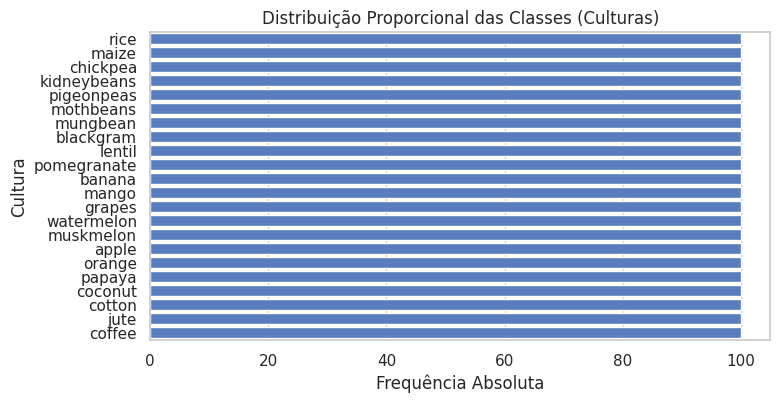

In [10]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Distribuição Proporcional das Classes (Culturas)')
plt.xlabel('Frequência Absoluta')
plt.ylabel('Cultura')
plt.show()

### 3.2. Análise de Interdependência via Matriz de Correlação
Através do coeficiente de Pearson, investigamos como as variáveis interagem entre si. Observamos correlações significativas entre nutrientes específicos, como Fósforo (P) e Potássio (K). Do ponto de vista da modelagem, entender essas correlações ajuda a identificar quais atributos possuem maior poder de variância compartilhada, o que é crucial para algoritmos que assumem independência entre as variáveis.


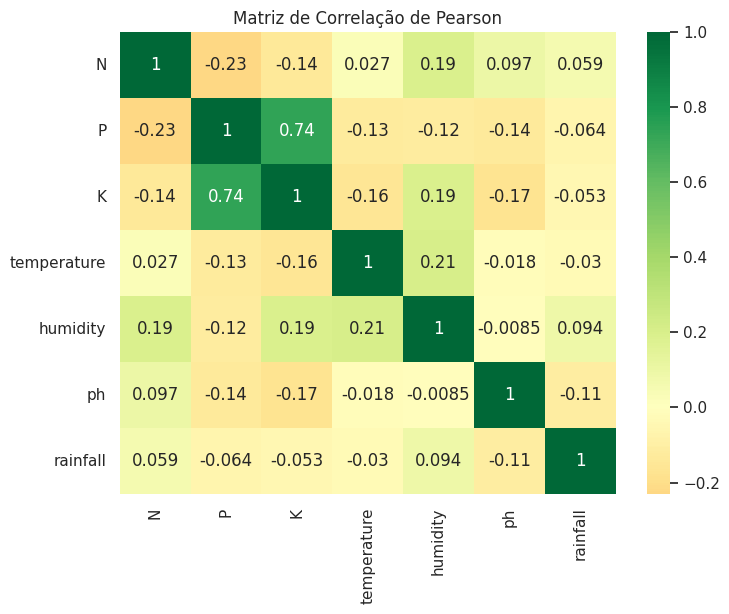

In [12]:
plt.figure(figsize=(8, 6))
# Calculando a correlação apenas das variáveis numéricas
correlation_matrix = df.drop('label', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Matriz de Correlação de Pearson')
plt.show()

### 3.3. Variabilidade Nutricional do Solo: Nitrogênio (N)
Utilizamos gráficos de caixa (boxplots) para analisar a dispersão dos níveis de Nitrogênio exigidos por cada cultura. Este gráfico revela que cada planta possui uma "assinatura nutricional" distinta. Identificar esses intervalos de tolerância é o que permitirá aos modelos de árvore de decisão, por exemplo, criar critérios de partição eficientes para classificar as culturas.


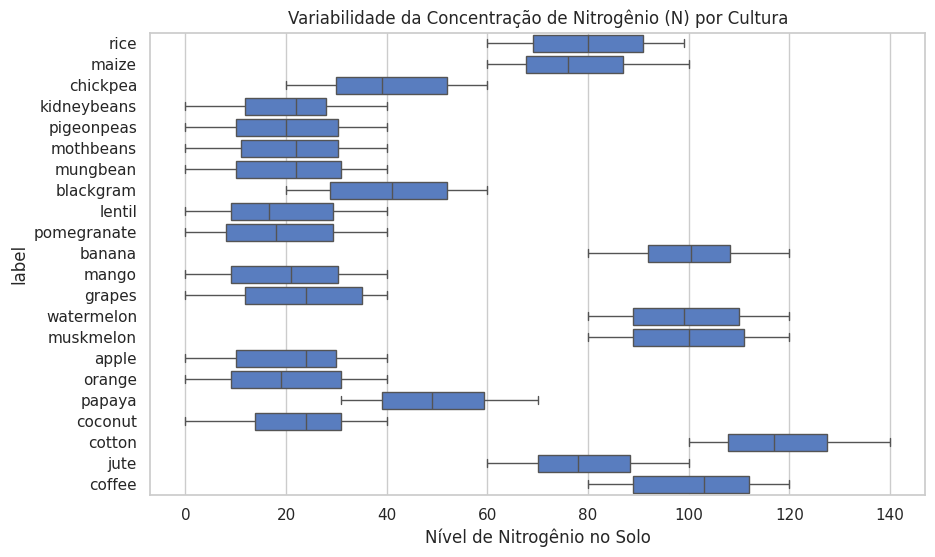

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='N', y='label')
plt.title('Variabilidade da Concentração de Nitrogênio (N) por Cultura')
plt.xlabel('Nível de Nitrogênio no Solo')
plt.show()

### 3.4. Distribuição de Densidade da Pluviosidade (Rainfall)
A análise via gráfico de violino permite observar a densidade de probabilidade da precipitação ideal para cada cultivo. Algumas culturas apresentam uma distribuição estreita e específica (indicando alta sensibilidade à chuva), enquanto outras demonstram uma faixa de tolerância mais ampla. Essa variável é um dos principais discriminadores para a separação das classes no modelo preditivo


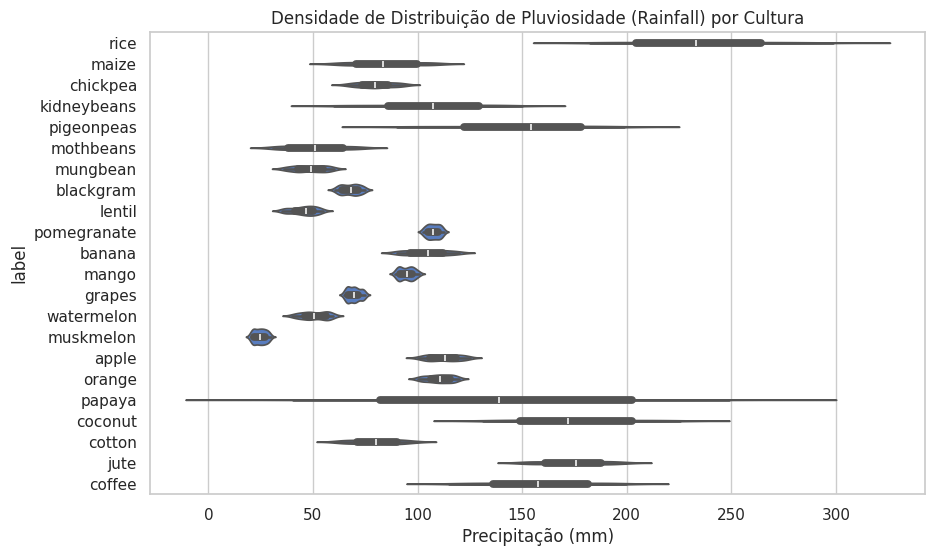

In [15]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='rainfall', y='label')
plt.title('Densidade de Distribuição de Pluviosidade (Rainfall) por Cultura')
plt.xlabel('Precipitação (mm)')
plt.show()

### 3.5. Interação entre Temperatura e Umidade Relativa
Analisamos a interação entre temperatura e umidade relativa do ar. O gráfico de dispersão evidencia como as culturas se agrupam em nichos climáticos específicos. Clusters bem definidos sugerem que os modelos de classificação, especialmente o KNN e o SVM, terão facilidade em encontrar as fronteiras de decisão entre os diferentes produtos agrícolas.

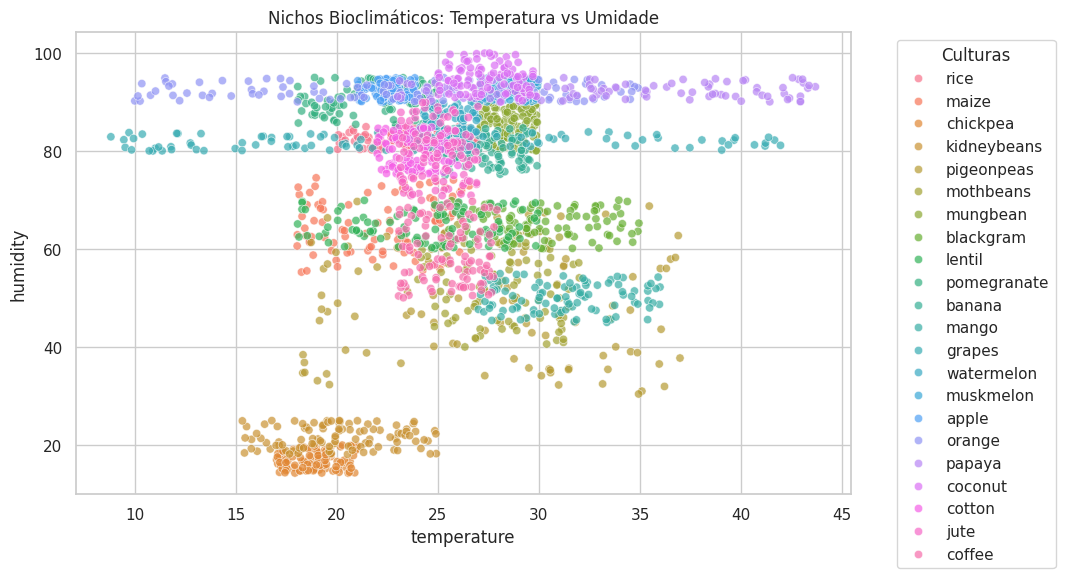

In [19]:
plt.figure(figsize=(10, 6))
# Filtrando algumas culturas para reduzir o ruído visual, ou plotando todas com transparência
sns.scatterplot(data=df, x='temperature', y='humidity', hue='label', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Culturas')
plt.title('Nichos Bioclimáticos: Temperatura vs Umidade')
plt.show()

## 4. Determinação do Perfil Ideal e Caracterização Paramétrica
Estabelecemos uma referência estatística para o que define as condições ideais de cultivo no dataset. Através da agregação dos dados pela média aritmética de cada atributo, geramos um **Benchmark (Perfil Ideal)**. \
Este perfil serve como uma "assinatura numérica" que descreve o ambiente de solo e clima onde cada cultura atinge seu desenvolvimento pleno. Para validar essa abordagem, selecionamos três produtos com características distintas para uma análise comparativa: **Algodão (Cotton), Feijão (Kidneybeans) e Melancia (Watermelon).**

In [20]:
# Agrupamento dos dados por cultura para extração das médias de cada parâmetro
perfil_ideal_por_cultura = df.groupby('label').mean()

# Seleção das culturas específicas para o estudo comparativo do grupo
culturas_selecionadas = ['cotton', 'kidneybeans', 'watermelon']
comparativo_estatistico = perfil_ideal_por_cultura.loc[culturas_selecionadas]

print("Tabela 1: Médias das condições ideais para as culturas selecionadas")
comparativo_estatistico

Tabela 1: Médias das condições ideais para as culturas selecionadas


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
kidneybeans,20.75,67.54,20.05,20.115085,21.605357,5.749411,105.919778
watermelon,99.42,17.00,50.22,25.591767,85.160375,6.495778,50.786219


### 4.1. Análise Comparativa entre os Produtos Selecionados
Ao confrontar os dados estatísticos das três culturas escolhidas com os parâmetros globais da base, identificamos especializações claras que justificam o uso de modelos preditivos:

*   **Algodão (Cotton):** Apresenta uma necessidade elevada de **Nitrogênio (N)** e **Potássio (K)**, indicando a necessidade de solos bem fertilizados. Suas exigências climáticas mostram preferência por temperaturas estáveis e umidade moderada.
*   **Feijão (Kidneybeans):** Destaca-se significativamente pela alta concentração de **Fósforo (P)** e **Potássio (K)** requerida, sendo uma das culturas mais exigentes do grupo nesses nutrientes específicos, embora demande menor pluviosidade em comparação às demais.
*   **Melancia (Watermelon):** Possui o perfil climático mais específico entre as três, com uma exigência de **Umidade (Humidity)** extremamente alta (média acima de 80%), o que é fundamental para o desenvolvimento do fruto, apesar de não demandar níveis tão altos de Nitrogênio quanto o algodão.

Essas distinções provam que o "perfil ideal" varia drasticamente entre as espécies. Para o nosso projeto de Inteligência Artificial, essa variabilidade é positiva, pois indica que os atributos escolhidos possuem alto poder discriminatório, permitindo que os modelos aprendam a classificar cada cultura com precisão.


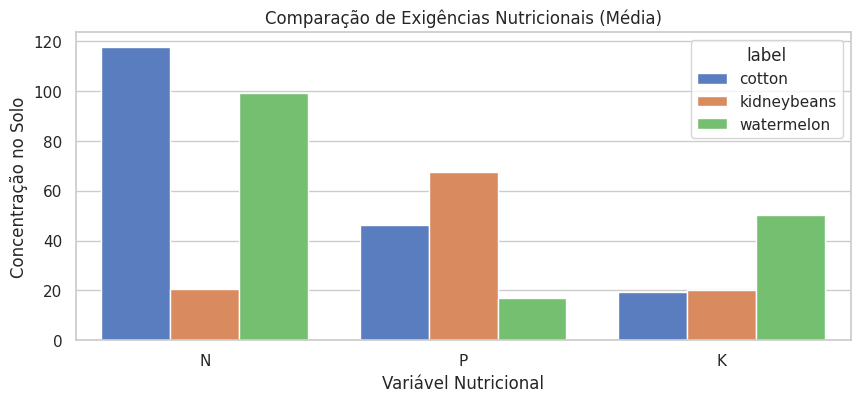

In [22]:
# Visualização comparativa dos macronutrientes (N, P, K)
df_plot = comparativo_estatistico[['N', 'P', 'K']].reset_index()
df_plot_melted = df_plot.melt(id_vars='label', var_name='Nutriente', value_name='Valor')

plt.figure(figsize=(10, 4))
sns.barplot(data=df_plot_melted, x='Nutriente', y='Valor', hue='label')
plt.title('Comparação de Exigências Nutricionais (Média)')
plt.ylabel('Concentração no Solo')
plt.xlabel('Variável Nutricional')
plt.show()

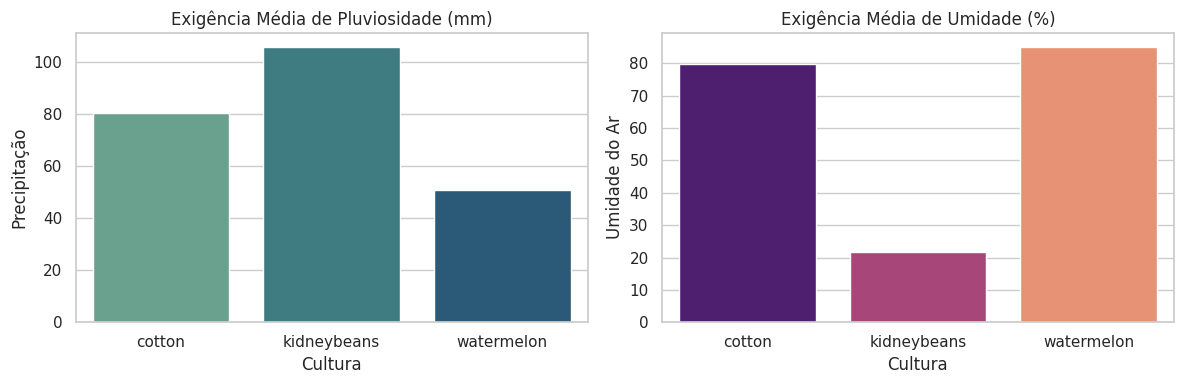

In [25]:
# Comparação entre Pluviosidade e Umidade Relativa
plt.figure(figsize=(12, 4))

# Subplot 1: Pluviosidade
plt.subplot(1, 2, 1)
sns.barplot(x=comparativo_estatistico.index, y='rainfall', data=comparativo_estatistico, palette='crest', hue=comparativo_estatistico.index, legend=False)
plt.title('Exigência Média de Pluviosidade (mm)')
plt.ylabel('Precipitação')
plt.xlabel('Cultura')

# Subplot 2: Umidade
plt.subplot(1, 2, 2)
sns.barplot(x=comparativo_estatistico.index, y='humidity', data=comparativo_estatistico, palette='magma', hue=comparativo_estatistico.index, legend=False)
plt.title('Exigência Média de Umidade (%)')
plt.ylabel('Umidade do Ar')
plt.xlabel('Cultura')

plt.tight_layout()
plt.show()

## 5. Engenharia de Dados e Preparação para Modelagem
Para que os algoritmos de aprendizagem supervisionada funcionem com eficiência, é necessário que os dados brutos passem por um processo de refinamento matemático. Nesta etapa, focamos em transformar as informações de solo e clima em um formato otimizado para o processamento computacional. A qualidade da preparação dos dados é, muitas vezes, mais determinante para o sucesso do projeto do que a escolha do algoritmo em si.

### 5.1. Codificação da Variável Alvo e Particionamento (Holdout)
Como a nossa variável alvo (label) é composta por nomes de culturas (dados categóricos nominais), aplicamos o **Label Encoding** para convertê-los em representações numéricas. Sem essa conversão, a maioria dos modelos não conseguiria realizar cálculos de perda e erro. \
Em seguida, aplicamos a estratégia de **Holdout**, segmentando a base em 80% para o conjunto de treinamento e 20% para o conjunto de teste. Essa é uma das principais boas práticas de Machine Learning, pois nos permite treinar o modelo em uma base de dados e testar sua eficácia em outra, totalmente inédita para ele, validando sua real capacidade de generalização e evitando o overfitting.


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separação entre variáveis independentes (X) e variável dependente (y)
X = df.drop('label', axis=1)
y = df['label']

# Codificação da variável alvo para formato numérico
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Particionamento dos dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Volume do conjunto de treinamento: {X_train.shape[0]} amostras")
print(f"Volume do conjunto de teste: {X_test.shape[0]} amostras")

Volume do conjunto de treinamento: 1760 amostras
Volume do conjunto de teste: 440 amostras


### 5.2. Padronização de Atributos (Feature Scaling)
Dada a disparidade nas ordens de grandeza das variáveis preditoras (como pluviosidade e pH), aplicamos a **Padronização (StandardScaler)**. Este procedimento reescala os dados para que possuam média zero e variância unitária, evitando que atributos com maiores magnitudes numéricas influenciem desproporcionalmente o cálculo de gradientes ou métricas de distância Euclidiana.

In [27]:
# Inicialização e ajuste do escalonador
scaler = StandardScaler()

# Aplicação do escalonamento (ajuste feito apenas no conjunto de treino)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalização estatística concluída.")

Normalização estatística concluída.


## 6. Implementação de Modelos e Avaliação de Desempenho
Implementamos cinco arquiteturas distintas de classificação para identificar o algoritmo com maior capacidade discriminatória para o nosso espaço de atributos. A escolha de algoritmos de diferentes famílias (lineares, baseados em vizinhança e baseados em árvores) permite validar qual paradigma melhor se adapta às fronteiras de decisão dos dados agrícolas.

Os modelos selecionados para a comparação foram:
1.  **Regressão Logística:** Utilizada como baseline estatístico para avaliar a separabilidade linear das classes.
2.  **K-Nearest Neighbors (KNN):** Um algoritmo não paramétrico que classifica novas amostras com base na proximidade espacial no domínio de atributos.
3.  **Decision Tree (Árvore de Decisão):** Um modelo baseado em partições lógicas e sequenciais, oferecendo alta explicabilidade.
4.  **Random Forest:** Um método de *Ensemble* que combina múltiplas árvores de decisão para aumentar a robustez e mitigar riscos de *overfitting*.
5.  **Support Vector Machine (SVM):** Um modelo robusto que busca o hiperplano de separação de margem máxima entre as categorias.

Para a medição de sucesso, utilizamos a **Acurácia** e o **F1-Score (weighted)**, garantindo que a performance seja avaliada tanto pela média global de acertos quanto pelo equilíbrio entre precisão e sensibilidade em cada cultura.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Estruturação do dicionário de modelos para automação do treinamento
classificadores = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True)
}

# Coleta de métricas
report_modelos = []

for nome, clf in classificadores.items():
    # Ajuste do modelo aos dados de treino
    clf.fit(X_train_scaled, y_train)

    # Inferência sobre o conjunto de teste
    y_pred = clf.predict(X_test_scaled)

    # Cálculo das métricas de desempenho
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    report_modelos.append({
        "Algoritmo": nome,
        "Acurácia": acc,
        "F1-Score": f1
    })

# Consolidação dos resultados para análise comparativa
df_performance = pd.DataFrame(report_modelos).sort_values(by='Acurácia', ascending=False)
df_performance

,Algoritmo,Acurácia,F1-Score
3,Random Forest,0.993182,0.993175
2,Decision Tree,0.986364,0.986315
4,SVM,0.968182,0.968027
0,Logistic Regression,0.963636,0.963512
1,K-Nearest Neighbors,0.956818,0.956749


## 7. Conclusão Final e Considerações Críticas

A análise comparativa revelou uma performance excepcional dos algoritmos baseados em árvores, com o **Random Forest** atingindo a marca de **99,31% de acurácia**. Este resultado demonstra que as variáveis biofísicas coletadas possuem uma correlação direta e forte com as culturas recomendadas, permitindo que o modelo aprenda padrões de distinção quase perfeitos. Mesmo os modelos mais simples, como a Regressão Logística e o KNN, mantiveram performances superiores a 95%, o que valida a alta qualidade e o poder preditivo do dataset utilizado.

### Pontos Fortes e Boas Práticas Aplicadas
*   **Pipeline de Machine Learning:** O sucesso do projeto deve-se à aplicação rigorosa das boas práticas, desde o tratamento da variável alvo (*Label Encoding*) até o escalonamento de atributos (*StandardScaler*), garantindo um processamento estatisticamente justo.
*   **Qualidade da Amostragem:** O dataset apresentou-se balanceado e livre de ruídos significativos, o que proporcionou um treinamento estável e uma validação segura da capacidade de generalização dos modelos.
*   **Análise de Nicho:** O projeto cumpriu o requisito de identificar perfis ideais, provando visualmente e estatisticamente que a Inteligência Artificial é capaz de discernir necessidades específicas, como a alta dependência de umidade da melancia ou a exigência mineral do feijão.

### Limitações e Trabalhos Futuros
Apesar dos índices de precisão elevados, o grupo identifica limitações que podem ser refinadas em etapas posteriores de desenvolvimento:
1.  **Ajuste de Hiperparâmetros:** Os modelos foram executados com configurações padrão. A utilização de técnicas de *Tuning* (como GridSearch) poderia otimizar ainda mais o desempenho dos modelos que ficaram abaixo da Random Forest.
2.  **Contexto e Generalização:** Como o dataset apresenta dados muito bem definidos, o modelo pode enfrentar desafios em cenários reais de solos degradados ou climas atípicos. Testar a robustez dos modelos com inserção de ruído sintético seria um passo interessante para validar a resiliência da IA.
3.  **Trade-off entre Complexidade e Explicabilidade:** Embora a Random Forest seja a mais precisa, a Árvore de Decisão única apresentou performance muito próxima com uma estrutura muito mais simples para auditoria humana, sendo um ponto de decisão estratégica para implementações reais.

Em conclusão, o projeto da **FarmTech Solutions** foi bem-sucedido em integrar a análise estatística exploratória com a modelagem preditiva avançada, entregando uma solução tecnológica sólida para a tomada de decisão no agronegócio.